In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import geopandas as gpd
from shapely.geometry import Point
import gstools as gs

In [2]:
pd.set_option('display.max_columns', None)

senate_general_indiv20 = pd.read_csv('../data/senate_general_indiv20.csv', dtype=str)
senate_general_indiv22 = pd.read_csv('../data/senate_general_indiv22.csv', dtype=str)

senate_general_indiv20['TRANSACTION_AMT'] = senate_general_indiv20['TRANSACTION_AMT'].astype(int)
senate_general_indiv22['TRANSACTION_AMT'] = senate_general_indiv22['TRANSACTION_AMT'].astype(int)

display(senate_general_indiv20.head())
display(senate_general_indiv22.head())

,CMTE_ID,IMAGE_NUM,TRANSACTION_TP,NAME,CITY,STATE,ZIP_CODE,EMPLOYER,OCCUPATION,TRANSACTION_DT,TRANSACTION_AMT,CAND_ID,CAND_NAME,CAND_PTY_AFFILIATION,CAND_OFFICE_ST
0,C00647842,202010089285059826,15,"LOMBARDO, ROBERT",MANCHESTER,NH,03102,ELECTRONICS FOR IMAGING INC,TRADE COMPLIANCE MANAGER,2020-09-08,275,S0NH00300,"O'DONNELL, JUSTIN F",LIB,NH
1,C00716340,202010089285059649,15,"FLOYD, WILLIAM",EVANSTON,IL,60201,RETIRED,RETIRED,2020-09-10,500,S0IL00543,"CURRAN, MARK",REP,IL
2,C00716340,202010089285059651,15,"GULLY, MICHAEL",QUINCY,IL,62305,GULLY TRANSPORTATION,TRUCK LINE EXECUTIVE,2020-09-07,1000,S0IL00543,"CURRAN, MARK",REP,IL
3,C00716340,202010089285059651,15,"GULLY, MICHAEL",QUINCY,IL,62305,GULLY TRANSPORTATION,TRUCK LINE EXECUTIVE,2020-09-07,250,S0IL00543,"CURRAN, MARK",REP,IL
4,C00716340,202010089285059661,15,"O'BRIEN, KATHLEEN",LAKE FOREST,IL,60045,SELF,ATTORNEY,2020-09-02,250,S0IL00543,"CURRAN, MARK",REP,IL


,CMTE_ID,IMAGE_NUM,TRANSACTION_TP,NAME,CITY,STATE,ZIP_CODE,EMPLOYER,OCCUPATION,TRANSACTION_DT,TRANSACTION_AMT,CAND_ID,CAND_NAME,CAND_PTY_AFFILIATION,CAND_OFFICE_ST
0,C00588772,202212089547742689,22Y,"MURPHY, PAMELA",STAMFORD,CT,069028004,NaN,NaN,2022-09-16,2900,S6NH00091,"HASSAN, MARGARET WOOD",DEM,NH
1,C00588772,202212089547734268,15,"BRIODY, ELIZABETH",DETROIT,MI,482325170,CULTURAL KEYS LLC,BUSINESS ANTHROPOLOGIST,2022-09-16,200,S6NH00091,"HASSAN, MARGARET WOOD",DEM,NH
2,C00588772,202212089547736565,15E,"WORKMAN, LINDA",NAPERVILLE,IL,605646011,NOT EMPLOYED,NOT EMPLOYED,2022-09-16,50,S6NH00091,"HASSAN, MARGARET WOOD",DEM,NH
3,C00588772,202212089547736566,15E,"FRIEDELL, MORRIS",BERKELEY,CA,947101522,NOT EMPLOYED,NOT EMPLOYED,2022-09-16,1000,S6NH00091,"HASSAN, MARGARET WOOD",DEM,NH
4,C00588772,202212089547739541,15E,"OWENS, NORMAN",EDINA,MN,554102732,UNISYS,IT CONSULTANT,2022-09-16,10,S6NH00091,"HASSAN, MARGARET WOOD",DEM,NH


In [3]:
# aggregate by zip code
agg20 = senate_general_indiv20.groupby('ZIP_CODE')['TRANSACTION_AMT'].sum().reset_index()
agg22 = senate_general_indiv22.groupby('ZIP_CODE')['TRANSACTION_AMT'].sum().reset_index()

In [4]:
# import first three columns of ../data/uszips.csv, display first row as five digit strings
uszips = pd.read_csv('../data/uszips.csv', usecols=['zip', 'lat', 'lng', 'state_id'])
uszips['zip'] = uszips['zip'].astype(str).str.zfill(5)

# merge the two dataframes on ZIP_CODE
agg = pd.merge(agg20, agg22, on='ZIP_CODE', how='outer', suffixes=('_20', '_22')).fillna(0)

# merge agg with uszips on ZIP_CODE and zip, remove rows in agg that do not have a match in uszips
agg = pd.merge(agg, uszips, left_on='ZIP_CODE', right_on='zip', how='inner')
agg = agg.drop(columns=['zip'])

agg["TRANSACTION_AMT_20"] = agg["TRANSACTION_AMT_20"].apply(lambda x: max(0, x))
agg["TRANSACTION_AMT_22"] = agg["TRANSACTION_AMT_22"].apply(lambda x: max(0, x))

agg["delta_log"] = np.log(agg['TRANSACTION_AMT_22'] + 1) - np.log(agg['TRANSACTION_AMT_20'] + 1)

agg["total"] = agg["TRANSACTION_AMT_20"] + agg["TRANSACTION_AMT_22"]
agg = agg[agg["total"] >= 50].copy()
# agg = agg[agg['lat'].isin(['WI'])].copy()
# agg = agg[agg['lng'] > np.quantile(agg['lng'], 0.85)].copy()
# pick western states in the contiguous US
agg = agg[agg['lng'] < -105].copy()
agg = agg[agg['lat'] > 25].copy()
agg = agg[agg['lat'] < 50].copy()
agg.shape

(3424, 8)

In [5]:
agg.head()

,ZIP_CODE,TRANSACTION_AMT_20,TRANSACTION_AMT_22,lat,lng,state_id,delta_log,total
11436,59003,1250.0,0.0,45.48179,-106.20153,MT,-7.131699,1250.0
11437,59008,150.0,0.0,45.07982,-109.07496,MT,-5.017280,150.0
11438,59011,2957.0,0.0,45.92453,-109.97244,MT,-7.992269,2957.0
11439,59012,1500.0,0.0,45.29922,-106.60060,MT,-7.313887,1500.0
11440,59014,630.0,0.0,45.15351,-108.66421,MT,-6.447306,630.0


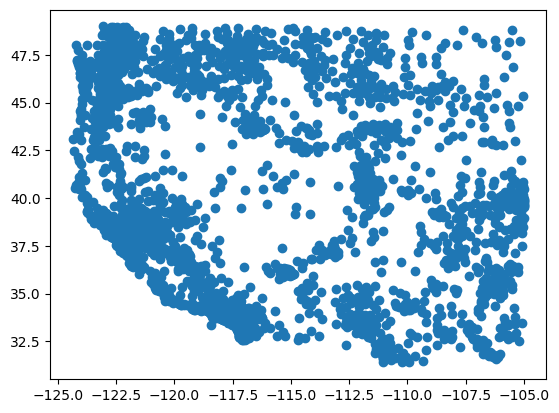

In [6]:
plt.plot(agg['lng'], agg['lat'], 'o', label='data points')

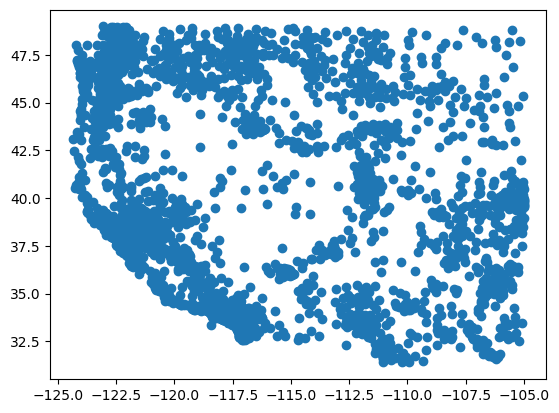

In [7]:
plt.plot(agg['lng'], agg['lat'], 'o', label='data points')

# Fitting models

## sample split

In [14]:
# sample split into 80% train, 20% test
train = agg.sample(frac=0.8, random_state=305)
test = agg.drop(train.index)

## and then fit

In [16]:
gdf = gpd.GeoDataFrame(
    train,
    geometry=gpd.points_from_xy(train["lng"], train["lat"]),
    crs="EPSG:4326"
)

# use a US projection (meters)
gdf = gdf.to_crs("EPSG:5070")  # NAD83 / Conus Albers

coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])
values = gdf["delta_log"].values

In [17]:
maxlag = 500_000   # 1000 km
n_lags = 15

bin_edges = np.linspace(0, maxlag, n_lags + 1)

bin_center, gamma, counts = gs.vario_estimate(
    (coords[:,0], coords[:,1]),
    values,
    bin_edges=bin_edges,
    return_counts=True
)

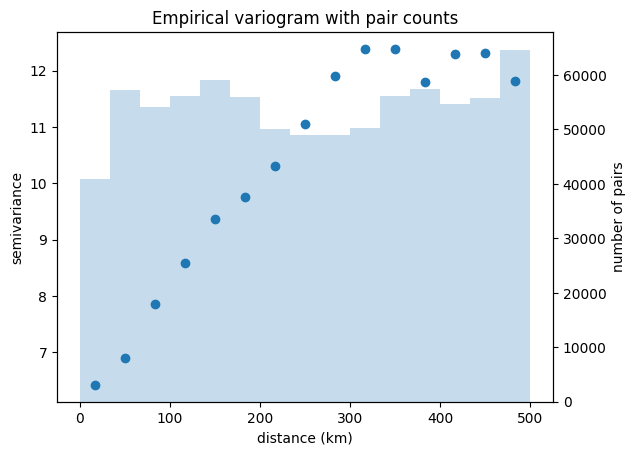

In [18]:
fig, ax1 = plt.subplots()

ax1.scatter(bin_center / 1000, gamma, label="empirical")
ax1.set_xlabel("distance (km)")
ax1.set_ylabel("semivariance")

ax2 = ax1.twinx()
ax2.bar(bin_center / 1000, counts, alpha=0.25, width=(maxlag / n_lags) / 1000)
ax2.set_ylabel("number of pairs")

plt.title("Empirical variogram with pair counts")
plt.show()

In [19]:
model_explore = gs.Spherical(dim=2)
model_explore.fit_variogram(bin_center, gamma)

print("range:", model_explore.len_scale)
print("sill:", model_explore.var)
print("nugget:", model_explore.nugget)

range: 382758.351530878
sill: 6.412659280779117
nugget: 5.765948913816943


In [20]:
model = gs.Spherical(
    dim=2,
    var=model_explore.var,          # sill
    len_scale=model_explore.len_scale,  # range
    nugget=model_explore.nugget       # nugget
)

krig = gs.krige.Ordinary(
    model,
    cond_pos=(coords[:,0], coords[:,1]),
    cond_val=values
)

In [22]:
# compute errors on test set
test_coords = np.column_stack([test['lng'], test['lat']])
test_coords = gpd.GeoSeries(gpd.points_from_xy(test['lng'], test['lat'])).set_crs("EPSG:4326").to_crs("EPSG:5070")
test_coords = np.column_stack([test_coords.x, test_coords.y])
test_values = test['delta_log'].values

results_test = krig(test_coords.T)

In [24]:
residuals = test_values - results_test[0] 

Text(0.5, 1.0, 'Error vs True Values')

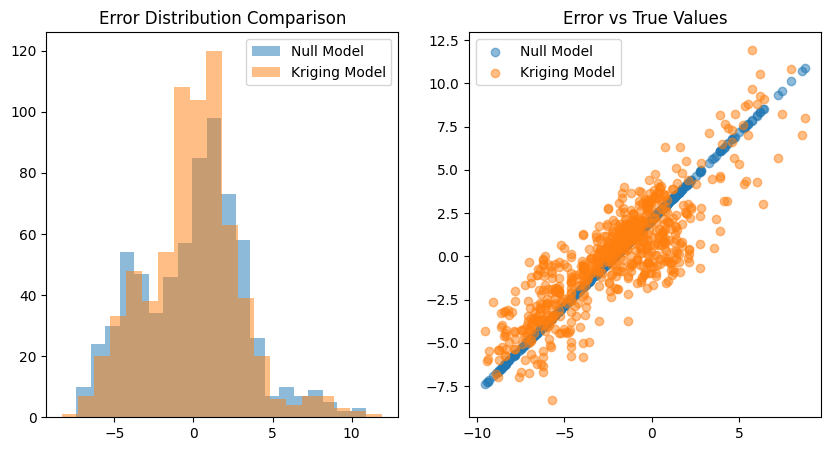

In [26]:
# null model predicts the mean of the training values
null_pred = np.mean(values)
null_errors = test_values - null_pred
krig_errors = test_values - results_test[0]

plt.figure(figsize = (10,5))
plt.subplot(1, 2, 1)
plt.hist(null_errors, bins=20, alpha=0.5, label='Null Model')
plt.hist(krig_errors, bins=20, alpha=0.5, label='Kriging Model')
plt.legend()
plt.title("Error Distribution Comparison")
plt.subplot(1, 2, 2)
plt.scatter(test_values, null_errors, alpha=0.5, label='Null Model')
plt.scatter(test_values, krig_errors, alpha=0.5, label='Kriging Model')
plt.legend()
plt.title("Error vs True Values")

In [30]:
np.mean(np.abs(null_errors)), np.mean(np.abs(krig_errors)), np.mean(np.abs(test_values))

(np.float64(2.6676409529914613),
 np.float64(2.268898532527709),
 np.float64(3.1279307346318346))